# Задание к лекции №5

АНАЛИЗ ВРЕМЕННЫХ РЯДОВ

мы рассмотрели различные способы представления событий, которые происходят в определенные моменты времени, а также методы обработки значений, изменяющихся с течением времени. Мы изучили объекты, использующиеся для представления даты и времени, объекты, представляющие интервалы и периоды, выполнили наиболее распространенные операции с временными рядами, включая преобразование частоты, передискретизацию шага и работу со скользящими окнами.

In [1]:
# Подготовка зависимостей
from datetime import datetime, date, time
import numpy as np
import pandas as pd
import pandas.tseries.offsets as offsets
import pandas.tseries.holiday as holiday
from pytz import common_timezones
import matplotlib.pyplot as plt

Ответить на вопросы и привести свои примеры, прикрепить на проверку:

1. Представление дат, времени и интервалов.

**Ответ**: Библиотека pandas предлагает встроенные средства для представления дат, времени и временных интервалов, поскольку в Python или NumPy таких инструментов, необходимых для обработки временных рядов, недостаточно.

Объект `datetime` является частью библиотеки `datetime`, а не частью библиотеки pandas. Этот класс можно использовать для построения объектов, представляющих несколько распространённых паттернов: фиксированный момент времени (дату и время), просто день без компонента времени или время без компонента даты. Объекты `datetime` не обеспечивают той точности, которая необходима большинству математиков, выполняющих тщательные расчёты на основе временных рядов. Однако именно они обычно используются для инициализации объектов pandas, и под капотом библиотека pandas преобразует их в объекты `Timestamp`.

- **`datetime.datetime`** — фиксированный момент времени (дата + время). Инициализируется тремя обязательными параметрами: год, месяц, день. По умолчанию часы и минуты равны 0.
- **`datetime.date`** — определённый день без компонента времени.
- **`datetime.time`** — определённое время без компонента даты.

Некоторые дополнительные возможности позволяют преобразовывать данные, меняя частоту, и использовать различные календари, чтобы учитывать в финансовых расчётах рабочие дни и праздники.

In [2]:
# Пример: объекты datetime, date, time

# Объект datetime.datetime с тремя обязательными параметрами (год, месяц, день)
dt = datetime(2023, 5, 4)
print("datetime:", dt)

# По умолчанию 0 часов и 0 минут; можно указать время явно
dt_with_time = datetime(2023, 5, 4, 12, 0)
print("datetime с временем 12:00:", dt_with_time)

# Текущие дата и время
now = datetime.now()
print("Текущие дата и время:", now)

# Объект datetime.date — день без компонента времени
d = date(2023, 5, 4)
print("date:", d)

# Текущая дата
today = date.today()
print("Текущая дата:", today)

# Объект datetime.time — время без компонента даты
t = time(12, 0, 0)
print("time:", t)

datetime: 2023-05-04 00:00:00
datetime с временем 12:00: 2023-05-04 12:00:00
Текущие дата и время: 2026-02-21 18:39:39.928814
date: 2023-05-04
Текущая дата: 2026-02-21
time: 12:00:00


2. Создание временной метки с помощью объекта Timestamp.

**Ответ**: В библиотеке pandas дату и время можно представить с помощью класса `pandas.tslib.Timestamp`. Объект pandas `Timestamp` основан на типе NumPy `datetime64` и имеет более высокую точность, чем питоновский объект `datetime`. В библиотеке pandas объекты `Timestamp` и объекты `datetime` обычно взаимозаменяемы, поэтому вы можете использовать объекты `Timestamp` везде, где можно использовать объекты `datetime`.

Вы можете создать объект `Timestamp` с помощью `pd.Timestamp` (ярлык для `pandas.tslib.Timestamp`), передав строку, представляющую дату, время или дату и время. Можно также указать компонент времени. Кроме того, объект `Timestamp` можно создать, задав лишь время, и по умолчанию будет добавлена местная текущая дата.

Обычно пользователи pandas не создают объекты `Timestamp` напрямую. Многие функции pandas, которые работают с датами и временем, позволяют принять в качестве аргумента объект `datetime` или текстовое представление даты/времени, а затем выполняют преобразование.

In [3]:
# Создаём объект Timestamp, передав строку с датой
ts1 = pd.Timestamp('2014-08-01')
print("Timestamp из строки с датой:", ts1)

# Создаём Timestamp с компонентом времени
ts2 = pd.Timestamp('2014-08-01 12:00:00')
print("Timestamp с временем:", ts2)

# Создаём Timestamp, задав только время (добавится текущая дата)
ts3 = pd.Timestamp('12:00:00')
print("Timestamp только из времени:", ts3)

# Получаем текущие дату и время с помощью объекта Timestamp
ts_now = pd.Timestamp('now')
print("Текущие дата и время через Timestamp:", ts_now)

Timestamp из строки с датой: 2014-08-01 00:00:00
Timestamp с временем: 2014-08-01 12:00:00
Timestamp только из времени: 2026-02-21 12:00:00
Текущие дата и время через Timestamp: 2026-02-21 18:39:39.932965


3. Использование объекта Timedelta для представления временного интервала.

**Ответ**: Для представления разности между двумя моментами времени используется объект библиотеки pandas `Timedelta`. Он используется для вычисления временного интервала между двумя датами или для вычисления даты, отстоящей от другой даты и/или времени на определённый промежуток времени.

In [4]:
# Используем объект Timedelta для вычисления даты, отстоящей
# от указанной даты на один день вперёд
d = datetime(2014, 8, 29)
next_day = d + pd.Timedelta('1 day')
print("Дата + 1 день:", next_day)

# Вычисляем количество дней между двумя датами
d1 = datetime(2014, 8, 29)
d2 = datetime(2014, 9, 5)
delta = pd.Timedelta(d2 - d1)
print("Интервал между датами:", delta)

Дата + 1 день: 2014-08-30 00:00:00
Интервал между датами: 7 days 00:00:00


4. Индексация с помощью DatetimeIndex.

**Ответ**: В основе работы с временными рядами лежит использование специализированных индексов. Эти индексы представляют собой измерения данных, зафиксированные по одной или нескольким временным меткам. В библиотеке pandas они являются объектами `DatetimeIndex`. Это невероятно функциональные объекты, и они позволяют автоматически выравнивать данные на основе дат и времени.

Объекты `DatetimeIndex` в библиотеке pandas можно создать несколькими способами:
- передав список объектов `datetime` в объект `Series`;
- передав список строк с датами — объект `Series` достаточно умён, чтобы распознать строку как объект `datetime` и выполнить преобразование;
- с помощью функции `pd.to_datetime()`, которая принимает последовательность объектов и преобразует их в объекты `Timestamp`, а те в свою очередь формируют объект `DatetimeIndex`. Если объект не удаётся преобразовать, библиотека pandas создаёт значение `NaT` (Not-a-Time);
- с помощью функции `pd.date_range()`, которая позволяет легко создать диапазон временных меток с определённой частотой.

Каждое значение объекта `DatetimeIndex` является объектом `Timestamp`. Элементы серии с типом `DatetimeIndex` можно извлекать с помощью строкового представления даты, не указывая объект `datetime`. Кроме того, можно создать срез, задав диапазон из строковых представлений дат, а также отбирать даты по году, месяцу и т.д.

In [5]:
# Создаём DatetimeIndex, передав список объектов datetime
dates = [datetime(2023, 5, 4), datetime(2023, 5, 11)]
ts = pd.Series(np.random.randn(2), dates)
print("Тип индекса:", type(ts.index))
print("Тип метки индекса:", type(ts.index[0]))

# Создаём временной ряд из списка дат в виде строк
np.random.seed(123456)
dates2 = ['2023-08-01', '2023-08-02']
ts2 = pd.Series(np.random.randn(2), dates2)
print(ts2)

# Используем pd.to_datetime() для преобразования разных форматов
dti = [pd.to_datetime(i) for i in ['Aug 1, 2014', '2014-08-02', '2014.8.3', None]]
for l in dti:
    print(l)

# Параметр errors='coerce': значения, которые нельзя преобразовать, получат NaT
print(pd.to_datetime(['Aug 1, 2014', 'foo'], errors='coerce'))

# Создаём диапазон из 10 последовательных дней с помощью pd.date_range()
np.random.seed(123456)
periods = pd.date_range('8/1/2014', periods=10)
date_series = pd.Series(np.random.randn(10), index=periods)
print(date_series)

# Срез по позициям индекса
subset = date_series[3:7]
print(subset)

# Выравнивание двух серий с DatetimeIndex
s2 = pd.Series([10, 100, 1000, 10000], subset.index)
print(date_series + s2)

Тип индекса: <class 'pandas.DatetimeIndex'>
Тип метки индекса: <class 'pandas.Timestamp'>
2023-08-01    0.469112
2023-08-02   -0.282863
dtype: float64
2014-08-01 00:00:00
2014-08-02 00:00:00
2014-08-03 00:00:00
NaT
DatetimeIndex(['2014-08-01', 'NaT'], dtype='datetime64[us]', freq=None)
2014-08-01    0.469112
2014-08-02   -0.282863
2014-08-03   -1.509059
2014-08-04   -1.135632
2014-08-05    1.212112
2014-08-06   -0.173215
2014-08-07    0.119209
2014-08-08   -1.044236
2014-08-09   -0.861849
2014-08-10   -2.104569
Freq: D, dtype: float64
2014-08-04   -1.135632
2014-08-05    1.212112
2014-08-06   -0.173215
2014-08-07    0.119209
Freq: D, dtype: float64
2014-08-01             NaN
2014-08-02             NaN
2014-08-03             NaN
2014-08-04        8.864368
2014-08-05      101.212112
2014-08-06      999.826785
2014-08-07    10000.119209
2014-08-08             NaN
2014-08-09             NaN
2014-08-10             NaN
Freq: D, dtype: float64


5. Создание временных рядов с определенными частотами.

**Ответ**: Частота временного ряда не обязательно должна быть ежедневной. С помощью функции `pd.date_range()` и параметра `freq` можно сгенерировать различные частоты. По умолчанию параметр `freq` имеет значение `'D'`, которое обозначает суточную частоту.

Чтобы создать временной ряд, состоящий только из рабочих дней, воспользуйтесь строковым значением `'B'`. С помощью параметра `period` можно создать диапазон, начинающийся с определённой даты и времени, с определённой частотой и с определённым количеством периодов.

Возможные частоты (основные из них):

| Обозначение | Описание                                 |
| ----------- | ---------------------------------------- |
| B           | Каждый рабочий день                      |
| C           | Каждый указанный рабочий день            |
| D           | Ежедневно (по умолчанию)                 |
| W           | Еженедельно                              |
| M           | Каждый последний календарный день месяца |
| BM          | Каждый последний рабочий день месяца     |
| MS          | Каждый первый календарный день месяца    |
| Q           | Ежеквартально                            |
| A           | Каждый последний день года               |
| H           | Ежечасно                                 |
| T           | Ежеминутно                               |
| S           | Ежесекундно                              |
| L           | Каждую миллисекунду                      |
| U           | Каждую микросекунду                      |

In [6]:
# Создаём объект Series, состоящий из 1-минутных интервалов
np.random.seed(123456)
bymin = pd.Series(np.random.randn(24*60*90),
                  pd.date_range('2014-08-01',
                                '2014-10-29 23:59',
                                freq='min'))
print(bymin[:5])

# Создаём срез с поминутными интервалами
print(bymin['2014-08-01 00:02':'2014-08-01 00:07'])

# Создаём серию, состоящую из рабочих дней
days = pd.date_range('2014-08-29', '2014-09-05', freq='B')
print(days)

# DatetimeIndex с 5 датами, начиная с 2014-08-01 12:10:01,
# с 5 посекундными интервалами
rng = pd.date_range('2014-08-01 12:10:01', periods=5, freq='s')
print(rng)

2014-08-01 00:00:00    0.469112
2014-08-01 00:01:00   -0.282863
2014-08-01 00:02:00   -1.509059
2014-08-01 00:03:00   -1.135632
2014-08-01 00:04:00    1.212112
Freq: min, dtype: float64
2014-08-01 00:02:00   -1.509059
2014-08-01 00:03:00   -1.135632
2014-08-01 00:04:00    1.212112
2014-08-01 00:05:00   -0.173215
2014-08-01 00:06:00    0.119209
2014-08-01 00:07:00   -1.044236
Freq: min, dtype: float64
DatetimeIndex(['2014-08-29', '2014-09-01', '2014-09-02', '2014-09-03',
               '2014-09-04', '2014-09-05'],
              dtype='datetime64[us]', freq='B')
DatetimeIndex(['2014-08-01 12:10:01', '2014-08-01 12:10:02',
               '2014-08-01 12:10:03', '2014-08-01 12:10:04',
               '2014-08-01 12:10:05'],
              dtype='datetime64[us]', freq='s')


6. Представление интервалов данных с помощью смещений дат.

**Ответ**: В библиотеке pandas для каждой базовой частоты определён объект, называемый смещением даты (date offset). Библиотека pandas расширяет возможности `Timedelta` с помощью объекта `DateOffset`. Объекты `DateOffset` содержат информацию о смещении времени и частоты, которую можно использовать для изменения объектов `DatetimeIndex`.

С помощью строковых значений `'M'`, `'W'`, `'BM'` и других, указываемых для параметра `freq` функции `pd.date_range()`, можно создавать объекты `DatetimeIndex` с разной частотой. Под капотом строковое значение будет преобразовано в экземпляр объекта `DateOffset`.

Объект `DateOffset` представляет собой приращение частоты. Смещения дат (например, «месяц», «рабочий день», «час») представлены в библиотеке pandas различными подклассами класса `DateOffset`. Класс `DateOffset` позволяет задать способ вычисления конкретного временного интервала на основе исходных даты и времени.

Объекты `DateOffset` можно использовать в различных сценариях:
- Их можно добавлять или вычитать для получения сдвинутой даты.
- Их можно умножить на целое число (положительное или отрицательное), чтобы приращение было применено несколько раз.
- У них есть методы `rollforward` и `rollback` для сдвига даты вперёд или назад к следующей или предыдущей «дате смещения».

Именованные аргументы объекта `DateOffset` делятся на два вида: абсолютные (год, месяц, день, час, минута, секунда, микросекунда) и относительные (годы, месяцы, недели, дни, часы, минуты, секунды, микросекунды — могут быть отрицательными).

In [7]:
# Создаём смещение на один день и прибавляем его к объекту datetime
d = datetime(2014, 8, 29)
print("Дата + 1 день (DateOffset):", d + offsets.DateOffset(days=1))

# Вычисляем дату, отстоящую на один рабочий день вперёд
print("Следующий рабочий день:", d + offsets.BusinessDay())

# Сдвиг сразу на несколько единиц с помощью умножения
print("Через 5 рабочих дней:", d + 5 * offsets.BusinessDay())

# Используем BMonthEnd для вычисления последнего рабочего дня
# месяца, следующего после 2014-09-02
d2 = datetime(2014, 9, 2)
print("Последний рабочий день месяца (BMonthEnd):", d2 + offsets.BMonthEnd())

# Метод rollforward для 2014-09-15
d3 = datetime(2014, 9, 15)
print("rollforward для 2014-09-15:", offsets.BMonthEnd().rollforward(d3))

# Дата вторника (weekday=1), предшествующего 2014-08-31
d4 = datetime(2014, 8, 31)
print("Предшествующий вторник:", offsets.Week(weekday=1).rollback(d4))

# Свойство .freq объекта DatetimeIndex
dti = pd.date_range('2014-08-29', '2014-09-05', freq='B')
print("Частота DatetimeIndex:", dti.freq)

Дата + 1 день (DateOffset): 2014-08-30 00:00:00
Следующий рабочий день: 2014-09-01 00:00:00
Через 5 рабочих дней: 2014-09-05 00:00:00
Последний рабочий день месяца (BMonthEnd): 2014-09-30 00:00:00
rollforward для 2014-09-15: 2014-09-30 00:00:00
Предшествующий вторник: 2014-08-26 00:00:00
Частота DatetimeIndex: <BusinessDay>


7. Привязка периодов к конкретным дням недели, месяца, квартала или года.

**Ответ**: Привязанные смещения — это определённые частоты, которые начинаются с определённого момента времени, например, с определённого дня недели, месяца или года. Для привязанных смещений используются заранее определённые сокращения.

Строковые значения для конкретных дней недели задают привязку к конкретному дню: например, для создания индекса из дат всех сред, приходящихся на промежуток между двумя указанными датами.

Привязанные смещения также можно создать с помощью ежегодных и ежеквартальных частот. Эти привязанные частоты имеют общий вид `[B][A|Q][S]-[MON]`, где `B` (рабочие дни) и `S` (начало периода вместо конца) задаются по желанию, `A` — частота ежегодно или `Q` — частота ежеквартально, а `MON` — трёхзначная аббревиатура для месяца (JAN, FEB, ...).

In [8]:
# Создаём индекс из дат всех сред между двумя датами
wednesdays = pd.date_range('2014-08-01', '2014-09-01', freq='W-WED')
print("Все среды:", wednesdays)

# Создаём четыре ежеквартальные даты (первый рабочий день
# последнего месяца квартала), год заканчивается в июне
quarterly = pd.date_range('2014-01-01', periods=4, freq='BQS-JUN')
print("Ежеквартальные даты (год заканчивается в июне):", quarterly)

Все среды: DatetimeIndex(['2014-08-06', '2014-08-13', '2014-08-20', '2014-08-27'], dtype='datetime64[us]', freq='W-WED')
Ежеквартальные даты (год заканчивается в июне): DatetimeIndex(['2014-03-03', '2014-06-02', '2014-09-01', '2014-12-01'], dtype='datetime64[us]', freq='BQS-JUN')


8. Моделирование интервала времени с помощью объекта Period.

**Ответ**: Чтобы упростить организацию и анализ данных за определённый промежуток времени, библиотека pandas позволяет создавать интервалы времени как формальную конструкцию с помощью класса `Period`.

Объект `Period` позволяет задать промежутки времени, исходя из различных частот (ежедневной, еженедельной, ежемесячной, ежеквартальной, ежегодной и т.д.). При этом он включает в себя начальную и конечную временные метки, задающие определённый интервал времени. Объект `Period` можно создать с помощью временной метки и частоты, при этом временная метка представляет собой «якорь», используемый в качестве точки отсчёта, а частота — это продолжительность времени.

Свойства `start_time` и `end_time` объекта `Period` сообщают о начальной и конечной временных метках. Прибавление 1 к объекту `Period` информирует его о том, что нужно осуществить сдвиг на одну положительную единицу частоты периода. Объект `Period` учитывает фактическое количество дней в каждом конкретном месяце (например, сентябрь состоит из 30 дней, а не из 31).

In [9]:
# Создаём период — один месяц, охватывающий август 2014 года
aug2014 = pd.Period('2014-08', freq='M')
print("Период август 2014:", aug2014)
print("start_time:", aug2014.start_time)
print("end_time:", aug2014.end_time)

# Сдвигаем вперёд на одну единицу частоты (один месяц)
sep2014 = aug2014 + 1
print("Следующий период (сентябрь 2014):", sep2014)
print("start_time сентября:", sep2014.start_time)
print("end_time сентября:", sep2014.end_time)

Период август 2014: 2014-08
start_time: 2014-08-01 00:00:00
end_time: 2014-08-31 23:59:59.999999
Следующий период (сентябрь 2014): 2014-09
start_time сентября: 2014-09-01 00:00:00
end_time сентября: 2014-09-30 23:59:59.999999


9. Индексация с помощью PeriodIndex.

**Ответ**: Серию объектов `Period` можно объединить в специальный тип индекса, известный как `PeriodIndex`. Индекс `PeriodIndex` применяется в том случае, когда данные нужно связать с определёнными временными интервалами, создать срезы и проанализировать события в каждом интервале.

`PeriodIndex` отличается от `DatetimeIndex` тем, что индексные метки являются объектами `Period`. Библиотека pandas определяет начальную и конечную даты каждого месяца, принимая во внимание фактическое количество дней в каждом конкретном месяце.

Как и `DatetimeIndex`, `PeriodIndex` можно использовать для индексации значений с помощью объекта `Period` или строкового значения, задающего спецификацию периода. Также можно создать срез объекта `PeriodIndex`.

In [10]:
# Создаём объект PeriodIndex, состоящий из 1-месячных интервалов 2013 года
mp2013 = pd.period_range('1/1/2013', '12/31/2013', freq='M')
print(mp2013)

# Печатаем начальную и конечную даты для всех объектов Period в индексе
for p in mp2013:
    print("{0} {1}".format(p.start_time, p.end_time))

# Создаём объект Series с индексом PeriodIndex на 2013 и 2014 годы
np.random.seed(123456)
ps = pd.Series(np.random.randn(24),
               pd.period_range('1/1/2013', '12/31/2014', freq='M'))
print(ps)

# Извлекаем значение, соответствующее периоду 2014-06
print(ps['2014-06'])

# Извлекаем значения для всех периодов в 2014 году
print(ps['2014'])

# Срез: значения с марта по июнь 2014 года
print(ps['2014-03':'2014-06'])

PeriodIndex(['2013-01', '2013-02', '2013-03', '2013-04', '2013-05', '2013-06',
             '2013-07', '2013-08', '2013-09', '2013-10', '2013-11', '2013-12'],
            dtype='period[M]')
2013-01-01 00:00:00 2013-01-31 23:59:59.999999
2013-02-01 00:00:00 2013-02-28 23:59:59.999999
2013-03-01 00:00:00 2013-03-31 23:59:59.999999
2013-04-01 00:00:00 2013-04-30 23:59:59.999999
2013-05-01 00:00:00 2013-05-31 23:59:59.999999
2013-06-01 00:00:00 2013-06-30 23:59:59.999999
2013-07-01 00:00:00 2013-07-31 23:59:59.999999
2013-08-01 00:00:00 2013-08-31 23:59:59.999999
2013-09-01 00:00:00 2013-09-30 23:59:59.999999
2013-10-01 00:00:00 2013-10-31 23:59:59.999999
2013-11-01 00:00:00 2013-11-30 23:59:59.999999
2013-12-01 00:00:00 2013-12-31 23:59:59.999999
2013-01    0.469112
2013-02   -0.282863
2013-03   -1.509059
2013-04   -1.135632
2013-05    1.212112
2013-06   -0.173215
2013-07    0.119209
2013-08   -1.044236
2013-09   -0.861849
2013-10   -2.104569
2013-11   -0.494929
2013-12    1.071804
2014-0

10. Обработка праздников с помощью календарей.

**Ответ**: По умолчанию библиотека pandas использует определённый календарь для расчёта следующего рабочего дня, и этот календарь не учитывает государственные праздники. Решение проблемы заключается в том, чтобы либо создать пользовательский календарь, либо воспользоваться календарём `USFederalHolidayCalendar`. Затем этот календарь можно передать объекту `CustomBusinessDay`, который будет использоваться вместо объекта `BusinessDay`. Вычисления, осуществляемые с помощью объекта `CustomBusinessDay`, будут использовать новый календарь и учитывать федеральные праздники США.

In [11]:
# Создаём календарь федеральных праздников США и выводим праздники 2014 года
cal = holiday.USFederalHolidayCalendar()
for d in cal.holidays(start='2014-01-01', end='2014-12-31'):
    print(d)

# Создаём объект CustomBusinessDay на основе календаря федеральных праздников США
cbd = offsets.CustomBusinessDay(holidays=cal.holidays())

# Вычисляем рабочий день, следующий после 2014-08-29 (с учётом Дня Труда)
print(datetime(2014, 8, 29) + cbd)

2014-01-01 00:00:00
2014-01-20 00:00:00
2014-02-17 00:00:00
2014-05-26 00:00:00
2014-07-04 00:00:00
2014-09-01 00:00:00
2014-10-13 00:00:00
2014-11-11 00:00:00
2014-11-27 00:00:00
2014-12-25 00:00:00
2014-09-02 00:00:00


11. Нормализация временных меток с помощью часовых поясов.

**Ответ**: Библиотека pandas поддерживает работу с временными метками, принадлежащими к разным часовым поясам. Под капотом для выполнения операций, связанных с часовыми поясами, pandas использует библиотеки `pytz` и `dateutil`. По умолчанию pandas использует библиотеку `pytz`. Объекты, которые учитывают часовые пояса, поддерживают свойство `.tz`. По умолчанию объекты pandas не используют объект `timezone`.

По умолчанию библиотека pandas обрабатывает `Timestamp('now')` как UTC-время, при этом информация о часовом поясе отсутствует. Аналогично `DatetimeIndex` и его объекты `Timestamp` по умолчанию не содержат информацию о часовом поясе.

Местное UTC-время можно вычислить, воспользовавшись методом `.tz_localize()` объекта `Timestamp`. С помощью параметра `tz` функции `pd.date_range()` можно создать индекс `DatetimeIndex` с определённым часовым поясом. Преобразовать часовой пояс в другой можно с помощью метода `.tz_convert()`.

Операции с несколькими временными рядами осуществляют выравнивание по объектам `Timestamp` в индексе, учитывая информацию о часовом поясе.

In [12]:
# Выводим первые 5 стандартных часовых поясов
print(common_timezones[:5])

# Получаем текущее время и преобразуем в UTC
now = pd.Timestamp("now")
local_now = now.tz_localize('UTC')
print(now, local_now)

# Создаём DatetimeIndex с определённым часовым поясом
rng = pd.date_range('3/6/2012 00:00', periods=5, freq='D', tz='US/Eastern')
print(rng)

# Создаём два объекта Series с разными часовыми поясами
s_mountain = pd.Series(np.arange(0, 5),
                       index=pd.date_range('2014-08-01',
                                           periods=5, freq='h',
                                           tz='US/Mountain'))
s_eastern = pd.Series(np.arange(0, 5),
                      index=pd.date_range('2014-08-01',
                                          periods=5, freq='h',
                                          tz='US/Eastern'))
print("s_mountain")
print(s_mountain)
print("s_eastern")
print(s_eastern)

# Складываем два объекта Series — выравнивание с учётом часовых поясов
print(s_eastern + s_mountain)

# Меняем часовой пояс с US/Eastern на US/Pacific
s_pacific = s_eastern.tz_convert("US/Pacific")
print(s_pacific)

['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara']
2026-02-21 18:39:40.101901 2026-02-21 18:39:40.101901+00:00
DatetimeIndex(['2012-03-06 00:00:00-05:00', '2012-03-07 00:00:00-05:00',
               '2012-03-08 00:00:00-05:00', '2012-03-09 00:00:00-05:00',
               '2012-03-10 00:00:00-05:00'],
              dtype='datetime64[us, US/Eastern]', freq='D')
s_mountain
2014-08-01 00:00:00-06:00    0
2014-08-01 01:00:00-06:00    1
2014-08-01 02:00:00-06:00    2
2014-08-01 03:00:00-06:00    3
2014-08-01 04:00:00-06:00    4
Freq: h, dtype: int64
s_eastern
2014-08-01 00:00:00-04:00    0
2014-08-01 01:00:00-04:00    1
2014-08-01 02:00:00-04:00    2
2014-08-01 03:00:00-04:00    3
2014-08-01 04:00:00-04:00    4
Freq: h, dtype: int64
2014-08-01 04:00:00+00:00    NaN
2014-08-01 05:00:00+00:00    NaN
2014-08-01 06:00:00+00:00    2.0
2014-08-01 07:00:00+00:00    4.0
2014-08-01 08:00:00+00:00    6.0
2014-08-01 09:00:00+00:00    NaN
2014-08-01 10:00:00+00:0

12. Сдвиг временного ряда с опережением и с запаздыванием.

**Ответ**: Одна из распространённых операций, использующихся в работе с временными рядами, заключается в перемещении данных назад и вперёд по временной оси. В библиотеке pandas для этого используется метод `.shift()`, который сдвигает значения серии или датафрейма на указанное количество единиц частоты в индексе. Библиотека pandas сдвигает значения на указанное количество единиц частоты, при этом сам индекс остаётся неизменным.

Запаздывание — это сдвиг в отрицательном направлении. Распространённая операция с помощью сдвига — вычисление ежедневного процентного изменения какого-то финансового показателя путём деления значений серии на те же значения, сдвинутые на 1.

Можно сдвинуть не значения, а сами временные метки — при этом индекс будет изменён, а значения останутся неизменными. Кроме того, временной ряд можно сдвинуть с помощью объекта `DateOffset`.

Метод `.tshift()` сдвигает индексные метки на указанное количество единиц определённой частоты, при этом частоту задают с помощью параметра `freq`.

In [13]:
# Создаём объект Series для демонстрации сдвига
np.random.seed(123456)
ts = pd.Series([1, 2, 2.5, 1.5, 0.5],
               pd.date_range('2014-08-01', periods=5))
print("Исходный ряд:")
print(ts)

# Сдвигаем значения на 1 день вперёд (опережение)
print("Сдвиг на 1 день вперёд:")
print(ts.shift(1))

# Сдвигаем значения на 2 дня назад (запаздывание)
print("Сдвиг на 2 дня назад:")
print(ts.shift(-2))

# Вычисляем ежедневное процентное изменение
print("Ежедневное процентное изменение:")
print(ts / ts.shift(1) - 1)

# Сдвигаем временные метки (индекс) на 1 рабочий день вперёд
print("Сдвиг индекса на 1 рабочий день вперёд:")
print(ts.shift(1, freq='B'))

# Сдвигаем даты на 5 часов вперёд
print("Сдвиг индекса на 5 часов вперёд:")
print(ts.shift(5, freq='h'))

# Сдвиг временного ряда с помощью объекта DateOffset (на 30 минут вперёд)
print("Сдвиг индекса на 30 минут вперёд:")
print(ts.shift(1, freq=offsets.DateOffset(minutes=30)))

Исходный ряд:
2014-08-01    1.0
2014-08-02    2.0
2014-08-03    2.5
2014-08-04    1.5
2014-08-05    0.5
Freq: D, dtype: float64
Сдвиг на 1 день вперёд:
2014-08-01    NaN
2014-08-02    1.0
2014-08-03    2.0
2014-08-04    2.5
2014-08-05    1.5
Freq: D, dtype: float64
Сдвиг на 2 дня назад:
2014-08-01    2.5
2014-08-02    1.5
2014-08-03    0.5
2014-08-04    NaN
2014-08-05    NaN
Freq: D, dtype: float64
Ежедневное процентное изменение:
2014-08-01         NaN
2014-08-02    1.000000
2014-08-03    0.250000
2014-08-04   -0.400000
2014-08-05   -0.666667
Freq: D, dtype: float64
Сдвиг индекса на 1 рабочий день вперёд:
2014-08-04    1.0
2014-08-04    2.0
2014-08-04    2.5
2014-08-05    1.5
2014-08-06    0.5
dtype: float64
Сдвиг индекса на 5 часов вперёд:
2014-08-01 05:00:00    1.0
2014-08-02 05:00:00    2.0
2014-08-03 05:00:00    2.5
2014-08-04 05:00:00    1.5
2014-08-05 05:00:00    0.5
Freq: D, dtype: float64
Сдвиг индекса на 30 минут вперёд:
2014-08-01 00:30:00    1.0
2014-08-02 00:30:00    2.0
2

13. Преобразование частоты временного ряда.

**Ответ**: Частоту временного ряда можно преобразовать с помощью метода `.asfreq()` объекта, в котором записан временной ряд. В результате преобразования частоты будет создан новый объект `Series` с индексом `DatetimeIndex`. Индекс `DatetimeIndex` нового объекта начинается с первой временной метки исходной серии и последовательно изменяется с определённой частотой вплоть до последней временной метки исходной серии. Затем происходит выравнивание значений.

Поскольку данные приводятся в соответствие с новым временным рядом, копируются только те значения, которые соответствуют точному времени наступления нового периода. При повышении частоты возникают значения `NaN` на метках, не соответствующих исходному ряду.

Этот результат можно изменить с помощью параметра `method` метода `.asfreq()`:
- `method='ffill'` (или `pad`) — прямое заполнение: использует последнее известное значение;
- `method='bfill'` — обратное заполнение.

In [14]:
# Создаём серию последовательно возрастающих значений —
# часовые интервалы всех дней августа 2014 года
periods = 31 * 24
hourly = pd.Series(np.arange(0, periods),
                   pd.date_range('08-01-2014', freq='h', periods=periods))
print("Ежечасный ряд (первые 5):")
print(hourly[:5])

# Преобразуем ежечасную частоту в ежесуточную
daily = hourly.asfreq('D')
print("Ежесуточный ряд (первые 5):")
print(daily[:5])

# Преобразуем обратно в ежечасную — появятся значения NaN
print("Обратно в ежечасную (первые 5):")
print(daily.asfreq('h')[:5])

# Прямое заполнение (ffill)
print("Прямое заполнение (ffill), первые 5:")
print(daily.asfreq('h', method='ffill')[:5])

# Обратное заполнение (bfill)
print("Обратное заполнение (bfill), первые 5:")
print(daily.asfreq('h', method='bfill')[:5])

Ежечасный ряд (первые 5):
2014-08-01 00:00:00    0
2014-08-01 01:00:00    1
2014-08-01 02:00:00    2
2014-08-01 03:00:00    3
2014-08-01 04:00:00    4
Freq: h, dtype: int64
Ежесуточный ряд (первые 5):
2014-08-01     0
2014-08-02    24
2014-08-03    48
2014-08-04    72
2014-08-05    96
Freq: D, dtype: int64
Обратно в ежечасную (первые 5):
2014-08-01 00:00:00    0.0
2014-08-01 01:00:00    NaN
2014-08-01 02:00:00    NaN
2014-08-01 03:00:00    NaN
2014-08-01 04:00:00    NaN
Freq: h, dtype: float64
Прямое заполнение (ffill), первые 5:
2014-08-01 00:00:00    0
2014-08-01 01:00:00    0
2014-08-01 02:00:00    0
2014-08-01 03:00:00    0
2014-08-01 04:00:00    0
Freq: h, dtype: int64
Обратное заполнение (bfill), первые 5:
2014-08-01 00:00:00     0
2014-08-01 01:00:00    24
2014-08-01 02:00:00    24
2014-08-01 03:00:00    24
2014-08-01 04:00:00    24
Freq: h, dtype: int64


14. Увеличение или уменьшение шага дискретизации временного ряда.

**Ответ**: Изменение шага дискретизации временного ряда отличается от преобразования частоты тем, что оно не выполняет выравнивание в чистом виде. Значения новой серии могут использовать параметры прямого и обратного заполнения, но их можно указать и с помощью других способов, предлагаемых библиотекой pandas, или с помощью собственных функций.

Изменение шага дискретизации (передискретизация) в библиотеке pandas выполняется с помощью метода `.resample()` и передачи в него новой частоты. Передискретизация фактически делит данные на интервалы на основе новых периодов, а затем применяет конкретную операцию к данным каждого интервала.

- **Понижающая передискретизация** — временной ряд имеет более низкую частоту и состоит из меньшего количества значений.
- **Повышающая передискретизация** — временной ряд имеет более высокую частоту; по умолчанию многие значения становятся `NaN`.

По умолчанию интервал закрыт слева. Другой сценарий — интервал, закрытый справа — реализуется с помощью параметра `close='right'`.

Для повышающей передискретизации можно использовать:
- `.bfill()` — обратное заполнение;
- `.interpolate()` — линейная интерполяция значений `NaN`.

Библиотека pandas предлагает ещё один удобный способ передискретизации — `open high low close` (`ohlc`), реализованный с помощью метода `.ohlc()`. Он часто используется в финансовых приложениях и вычисляет для каждого интервала четыре значения: первое (open), максимальное (high), минимальное (low) и последнее (close).

In [15]:
# Генерируем случайное блуждание за 5 дней по 1-секундным интервалам
count = 24 * 60 * 60 * 5
np.random.seed(123456)
values = np.random.randn(count)
ws = pd.Series(values)
walk = ws.cumsum()
walk.index = pd.date_range('2014-08-01', periods=count, freq='s')
print("Случайное блуждание (первые 5):")
print(walk[:5])

# Уменьшаем шаг дискретизации: из 1-секундных в 1-минутные (среднее)
print("Понижающая передискретизация — среднее по минутам (первые 5):")
print(walk.resample('1min').mean()[:5])

# Первое значение в каждом интервале
print("Первое значение в каждом минутном интервале (первые 5):")
print(walk.resample('1min').first()[:5])

# Повышающая передискретизация: из 1-минутных в 1-секундные
bymin = walk.resample('1min').mean()
print("Повышающая передискретизация (первые 5, с NaN):")
print(bymin.resample('s').mean()[:5])

# Обратное заполнение при повышающей передискретизации
print("Обратное заполнение (bfill), первые 5:")
print(bymin.resample('s').bfill()[:5])

# Линейная интерполяция значений NaN
interpolated = bymin.resample('s').interpolate()
print("Интерполяция (первые 5):")
print(interpolated[:5])

# Передискретизация ohlc
ohlc = walk.resample('h').ohlc()
print("OHLC (первые 5):")
print(ohlc[:5])

Случайное блуждание (первые 5):
2014-08-01 00:00:00    0.469112
2014-08-01 00:00:01    0.186249
2014-08-01 00:00:02   -1.322810
2014-08-01 00:00:03   -2.458442
2014-08-01 00:00:04   -1.246330
Freq: s, dtype: float64
Понижающая передискретизация — среднее по минутам (первые 5):
2014-08-01 00:00:00    -8.718220
2014-08-01 00:01:00   -15.239213
2014-08-01 00:02:00    -9.179315
2014-08-01 00:03:00    -8.338307
2014-08-01 00:04:00    -8.129554
Freq: min, dtype: float64
Первое значение в каждом минутном интервале (первые 5):
2014-08-01 00:00:00     0.469112
2014-08-01 00:01:00   -10.886314
2014-08-01 00:02:00   -13.374656
2014-08-01 00:03:00    -7.647693
2014-08-01 00:04:00    -4.482292
Freq: min, dtype: float64
Повышающая передискретизация (первые 5, с NaN):
2014-08-01 00:00:00   -8.71822
2014-08-01 00:00:01        NaN
2014-08-01 00:00:02        NaN
2014-08-01 00:00:03        NaN
2014-08-01 00:00:04        NaN
Freq: s, dtype: float64
Обратное заполнение (bfill), первые 5:
2014-08-01 00:00:0

15. Применение к временному ряду операций на основе скользящего окна.

**Ответ**: Библиотека pandas предлагает ряд функций, позволяющих вычислять статистики, меняющиеся со временем (скользящие статистики). В рамках подхода «скользящее окно» библиотека pandas вычисляет статистику по «окну» данных, представляющему определённый период времени. Затем окно смещается на определённый интервал времени и статистика постоянно вычисляется для каждого нового окна до тех пор, пока окно охватывает даты временного ряда. Библиотека pandas поддерживает скользящие оконные функции с помощью метода `.rolling()` объекта `Series` и объекта `DataFrame`.

Основные функции скользящего окна:

| Функция                 | Описание                                                    |
| ----------------------- | ----------------------------------------------------------- |
| `.rolling().mean()`     | Среднее значение в окне                                     |
| `.rolling().std()`      | Стандартное отклонение в окне                               |
| `.rolling().var()`      | Дисперсия в окне                                            |
| `.rolling().min()`      | Минимальное значение в окне                                 |
| `.rolling().max()`      | Максимальное значение в окне                                |
| `.rolling().cov()`      | Коэффициент ковариации в окне                               |
| `.rolling().quantile()` | Оценка для заданного процентиля/выборочного квантиля в окне |
| `.rolling().corr()`     | Коэффициент корреляции в окне                               |
| `.rolling().median()`   | Медиана в окне                                              |
| `.rolling().sum()`      | Сумма в окне                                                |
| `.rolling().apply()`    | Применение пользовательской функции к значениям окна        |
| `.rolling().count()`    | Количество непропущенных значений в окне                    |
| `.rolling().skew()`     | Коэффициент асимметрии в окне                               |
| `.rolling().kurt()`     | Коэффициент эксцесса в окне                                 |

На практике скользящее среднее используется для сглаживания краткосрочных колебаний и более чёткого выделения долгосрочных тенденций. Более широкое окно даёт меньший разброс значений, а более узкие окна приведут к более высокому разбросу значений (до тех пор, пока размер окна не станет равным 1, что идентично исходному временному ряду).

Обратите внимание, что чем больше окно, тем больше данных отсутствует в начале кривой. Для первоначального вычисления метрики окну размера n требуется n точек данных.

С помощью метода `.rolling().apply()` к значениям, попавшим в окно, можно применить любую пользовательскую функцию. Этой функции передаётся массив значений окна, и возвращается одно значение.

Среднее значение с расширяющимся окном можно вычислить с помощью метода `expanding()` — оно многократно вычисляет среднее значение, всегда начиная с первого значения временного ряда и в каждой итерации увеличивая размер окна на единицу. Среднее с расширяющимся окном будет более стабильным показателем, чем обычное скользящее среднее.

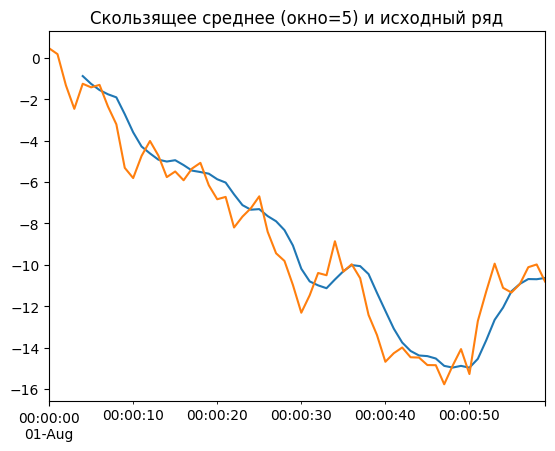

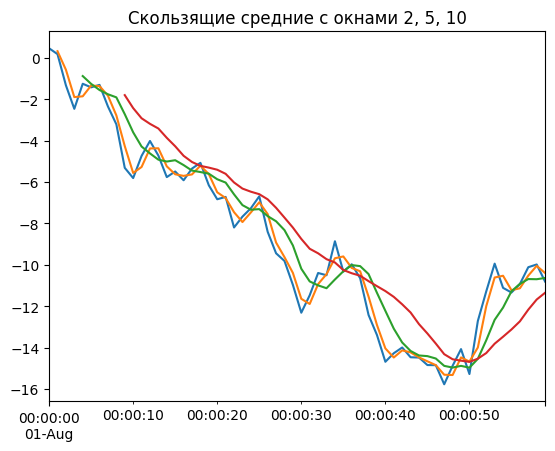

Среднее абсолютное отклонение (первые 10):
2014-08-01 00:00:00         NaN
2014-08-01 00:00:01         NaN
2014-08-01 00:00:02         NaN
2014-08-01 00:00:03         NaN
2014-08-01 00:00:04    0.961700
2014-08-01 00:00:05    0.577708
2014-08-01 00:00:06    0.363580
2014-08-01 00:00:07    0.518130
2014-08-01 00:00:08    0.697645
2014-08-01 00:00:09    1.233866
Freq: s, dtype: float64


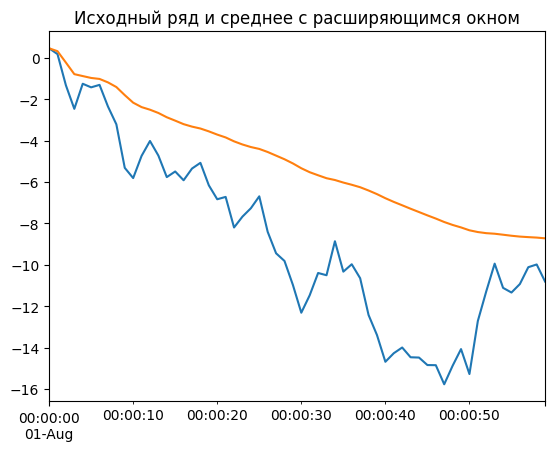

In [16]:
# Генерируем случайное блуждание за 5 дней по 1-секундным интервалам
count = 24 * 60 * 60 * 5
np.random.seed(123456)
values = np.random.randn(count)
ws = pd.Series(values)
walk = ws.cumsum()
walk.index = pd.date_range('2014-08-01', periods=count, freq='s')

# Извлекаем данные по одному 1-минутному интервалу
first_minute = walk['2014-08-01 00:00']

# Вычисляем скользящее среднее с шириной окна 5 периодов
means = first_minute.rolling(window=5, center=False).mean()
means.plot()
first_minute.plot()
plt.title("Скользящее среднее (окно=5) и исходный ряд")
plt.show()

# Демонстрируем разницу между скользящими окнами шириной 2, 5 и 10
h1w = walk['2014-08-01 00:00']
means2 = h1w.rolling(window=2, center=False).mean()
means5 = h1w.rolling(window=5, center=False).mean()
means10 = h1w.rolling(window=10, center=False).mean()
h1w.plot()
means2.plot()
means5.plot()
means10.plot()
plt.title("Скользящие средние с окнами 2, 5, 10")
plt.show()

# Применяем пользовательскую функцию (среднее абсолютное отклонение)
mad = first_minute.rolling(window=5, center=False).apply(
    lambda x: np.abs(x - x.mean()).mean(), raw=True)
print("Среднее абсолютное отклонение (первые 10):")
print(mad[:10])

# Среднее с расширяющимся окном
h1w.plot()
expanding = h1w.expanding(min_periods=1).mean()
expanding.plot()
plt.title("Исходный ряд и среднее с расширяющимся окном")
plt.show()

In [17]:
# Экспорт в html
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", __vsc_ipynb_file__])

[NbConvertApp] Converting notebook /Users/efim/dev/university-6sem-data-analysis/topic5/questions5/questions5.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 555934 bytes to /Users/efim/dev/university-6sem-data-analysis/topic5/questions5/questions5.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '/Users/efim/dev/university-6sem-data-analysis/topic5/questions5/questions5.ipynb'], returncode=0)